Jupyter Notebook Structure

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Customer Retention Analysis
8. Revenue Analysis
9. Correlation Analysis
10. Business Insights
11. Final Conclusion

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns",None)

Load Dataset

In [3]:
df = pd.read_csv("/content/ecommerce_customer_behavior_5000.csv")


Data Understanding and Inspection


In [5]:
df.head()



,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05


In [6]:
df.tail()



,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
4995,4996,18,Female,Groceries,Credit Card,420.44,7,1.3,Yes,2035-09-05
4996,4997,19,Male,Sports,UPI,1389.97,2,1.2,Yes,2035-09-06
4997,4998,42,Male,Sports,Credit Card,845.66,4,1.3,Yes,2035-09-07
4998,4999,46,Other,Sports,Credit Card,1077.51,3,2.6,Yes,2035-09-08
4999,5000,60,Male,Sports,UPI,290.47,8,1.5,Yes,2035-09-09


In [7]:
df.sample(5)



,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
4384,4385,28,Female,Sports,Debit Card,1374.83,2,1.6,No,2034-01-02
4583,4584,47,Male,Home & Living,Wallet,982.27,6,3.6,Yes,2034-07-20
4975,4976,28,Male,Sports,Debit Card,1237.25,4,3.5,No,2035-08-16
1559,1560,47,Other,Fashion,Cash on Delivery,566.65,5,2.6,Yes,2026-04-09
2921,2922,43,Male,Electronics,UPI,78.67,9,1.0,Yes,2029-12-31


In [8]:
df.shape



(5000, 10)

In [9]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            5000 non-null   int64  
 1   customer_age        5000 non-null   int64  
 2   customer_gender     5000 non-null   object 
 3   product_category    5000 non-null   object 
 4   payment_method      5000 non-null   object 
 5   order_value_usd     5000 non-null   float64
 6   delivery_time_days  5000 non-null   int64  
 7   customer_rating     5000 non-null   float64
 8   returned            5000 non-null   object 
 9   order_date          5000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 390.8+ KB


In [10]:
df.describe(include="all")



,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
count,5000.000000,5000.000000,5000,5000,5000,5000.000000,5000.00000,5000.000000,5000,5000
unique,NaN,NaN,3,6,5,NaN,NaN,NaN,2,5000
top,NaN,NaN,Male,Beauty,UPI,NaN,NaN,NaN,Yes,2035-09-09
freq,NaN,NaN,1709,853,1031,NaN,NaN,NaN,2525,1
mean,2500.500000,43.263400,NaN,NaN,NaN,749.672238,7.47300,3.015720,NaN,NaN
std,1443.520003,15.000847,NaN,NaN,NaN,430.370938,4.03293,1.148516,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,5.570000,1.00000,1.000000,NaN,NaN
25%,1250.750000,30.000000,NaN,NaN,NaN,367.087500,4.00000,2.000000,NaN,NaN
50%,2500.500000,43.000000,NaN,NaN,NaN,760.285000,7.00000,3.000000,NaN,NaN
75%,3750.250000,56.000000,NaN,NaN,NaN,1120.752500,11.00000,4.000000,NaN,NaN


In [14]:



df.dtypes



,0
order_id,int64
customer_age,int64
customer_gender,object
product_category,object
payment_method,object
order_value_usd,float64
delivery_time_days,int64
customer_rating,float64
returned,object
order_date,object


In [15]:
df.columns



Index(['order_id', 'customer_age', 'customer_gender', 'product_category',
       'payment_method', 'order_value_usd', 'delivery_time_days',
       'customer_rating', 'returned', 'order_date'],
      dtype='object')

**DATA CLEANING**

Missing Values

In [16]:
df.isnull().sum()

,0
order_id,0
customer_age,0
customer_gender,0
product_category,0
payment_method,0
order_value_usd,0
delivery_time_days,0
customer_rating,0
returned,0
order_date,0


In [17]:
(df.isnull().sum()/len(df))*100

,0
order_id,0.0
customer_age,0.0
customer_gender,0.0
product_category,0.0
payment_method,0.0
order_value_usd,0.0
delivery_time_days,0.0
customer_rating,0.0
returned,0.0
order_date,0.0


In [19]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_747/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [20]:
df.fillna(df.median(numeric_only=True), inplace=True)

Duplicate Records


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

Convert Date

In [23]:
df['order_date'] = pd.to_datetime(df['order_date'])

Check Invalid Values

In [24]:
for col in df.columns:
    print(col)
    print(df[col].unique())

order_id
[   1    2    3 ... 4998 4999 5000]
customer_age
[37 41 30 58 59 25 56 40 19 66 46 32 27 48 54 38 44 33 61 21 35 67 26 28
 52 24 23 42 55 57 36 39 60 64 34 63 69 65 47 62 22 49 43 50 29 45 20 68
 51 18 53 31]
customer_gender
['Other' 'Female' 'Male']
product_category
['Home & Living' 'Fashion' 'Sports' 'Electronics' 'Groceries' 'Beauty']
payment_method
['Wallet' 'Cash on Delivery' 'Debit Card' 'Credit Card' 'UPI']
order_value_usd
[1366.6  1175.89 1283.97 ...  845.66 1077.51  290.47]
delivery_time_days
[10  6  7 14 11  3  5  9 13  1  2 12  4  8]
customer_rating
[2.3 1.8 3.2 3.8 2.8 3.1 1.2 2.  3.3 3.  4.7 3.7 4.9 2.7 1.6 4.4 2.6 1.9
 4.6 4.5 4.8 2.1 2.9 2.5 3.5 1.1 3.4 3.9 2.4 5.  4.  1.  4.3 4.2 1.5 1.7
 1.3 3.6 1.4 4.1 2.2]
returned
['No' 'Yes']
order_date
<DatetimeArray>
['2022-01-01 00:00:00', '2022-01-02 00:00:00', '2022-01-03 00:00:00',
 '2022-01-04 00:00:00', '2022-01-05 00:00:00', '2022-01-06 00:00:00',
 '2022-01-07 00:00:00', '2022-01-08 00:00:00', '2022-01-09 00:00:00

**Outlier** **Detection**

Boxplot

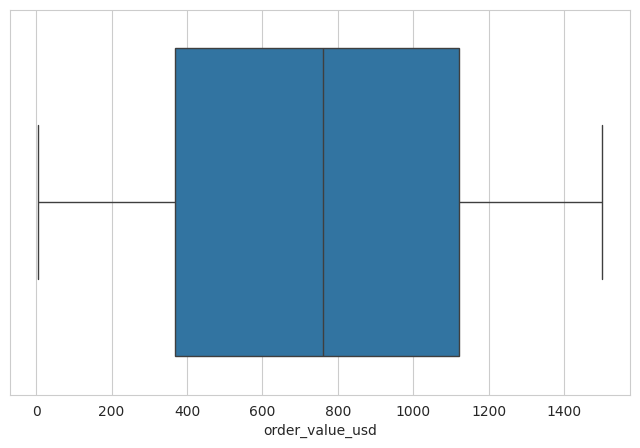

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['order_value_usd'])
plt.show()

IQR Method

In [27]:
Q1=df['order_value_usd'].quantile(0.25)
Q3=df['order_value_usd'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df['order_value_usd']<lower)|(df['order_value_usd']>upper)]

outliers

,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date


Feature Engineering -
Extract useful information

In [28]:
df['Month']=df['order_date'].dt.month_name()

In [29]:
df['Year']=df['order_date'].dt.year

In [ ]:
df['Day']=df['order_date'].dt.day_name()

In [30]:
df['Revenue_Category']=pd.cut(df['order_value_usd'],
                              bins=[0,100,300,600,1000],
                              labels=['Low','Medium','High','Premium'])

In [31]:
df['Age_Group']=pd.cut(df['customer_age'],
                       bins=[18,25,35,45,60,80],
                       labels=['18-25','26-35','36-45','46-60','60+'])

In [32]:
df['Delivery_Type']=np.where(df['delivery_time_days']<=3,
                             'Fast',
                             'Slow')

**Exploratory Data Analysis**

Data overview

In [33]:
df.describe()

,order_id,customer_age,order_value_usd,delivery_time_days,customer_rating,order_date,Year
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000,5000.000000
mean,2500.500000,43.263400,749.672238,7.47300,3.015720,2028-11-04 12:00:00,2028.352800
min,1.000000,18.000000,5.570000,1.00000,1.000000,2022-01-01 00:00:00,2022.000000
25%,1250.750000,30.000000,367.087500,4.00000,2.000000,2025-06-03 18:00:00,2025.000000
50%,2500.500000,43.000000,760.285000,7.00000,3.000000,2028-11-04 12:00:00,2028.000000
75%,3750.250000,56.000000,1120.752500,11.00000,4.000000,2032-04-07 06:00:00,2032.000000
max,5000.000000,69.000000,1499.370000,14.00000,5.000000,2035-09-09 00:00:00,2035.000000
std,1443.520003,15.000847,430.370938,4.03293,1.148516,NaN,3.954827


Correlation analysis

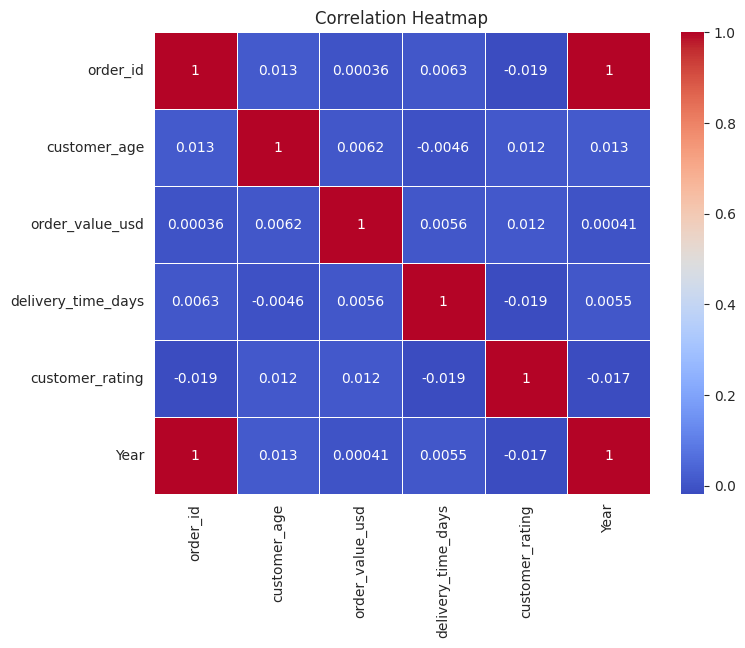

In [34]:
corr=df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Sales Trend

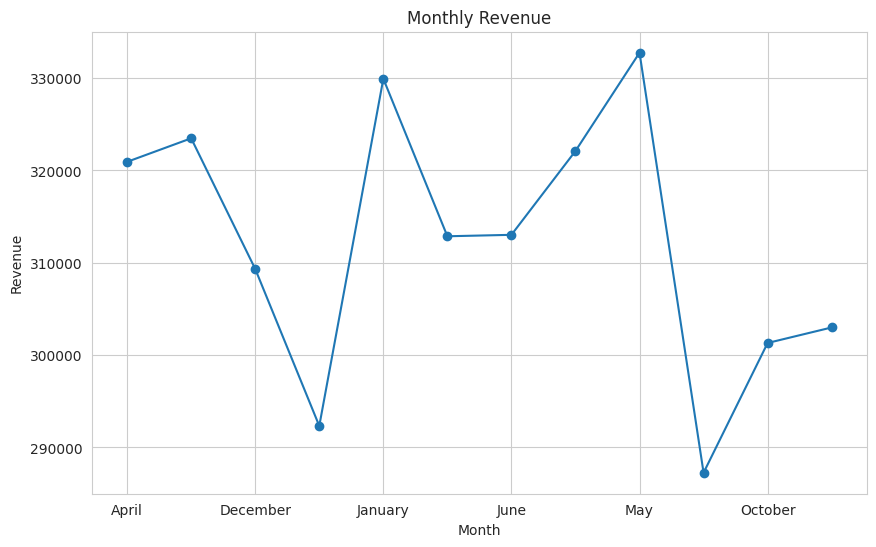

In [35]:
monthly=df.groupby("Month")["order_value_usd"].sum()

monthly.plot(marker='o')
plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.show()

Revenue by Product Category

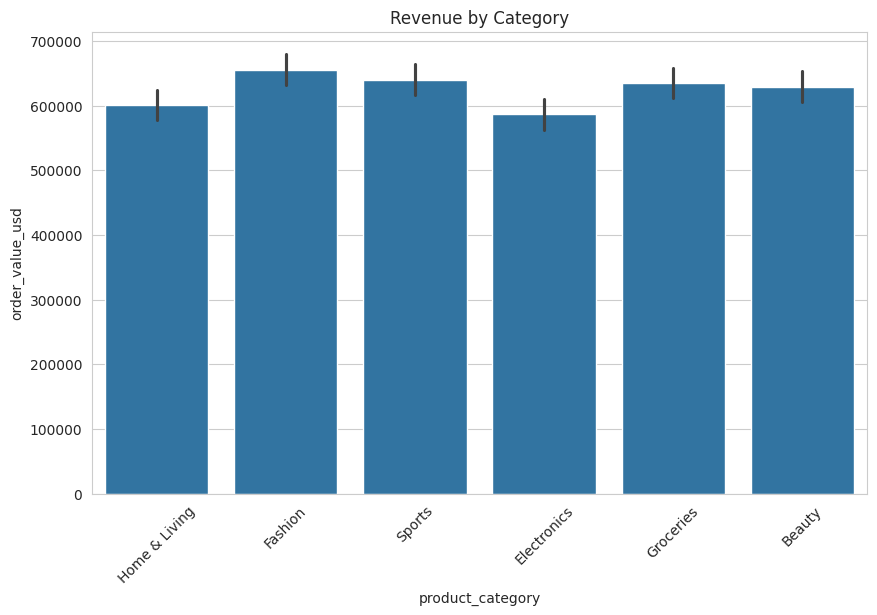

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(data=df,
            x='product_category',
            y='order_value_usd',
            estimator=np.sum)

plt.xticks(rotation=45)
plt.title("Revenue by Category")
plt.show()

Customer Age Distribution

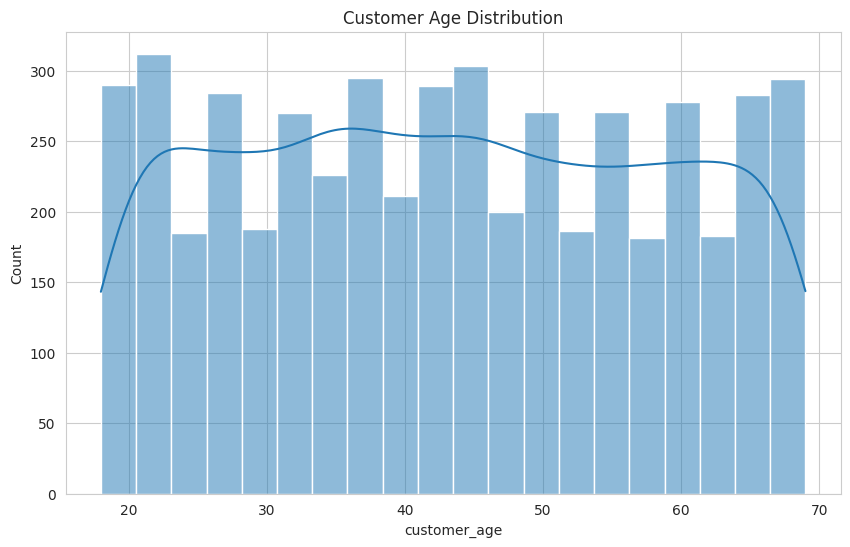

In [37]:
sns.histplot(df['customer_age'],
             bins=20,
             kde=True)

plt.title("Customer Age Distribution")
plt.show()

Gender Distribution

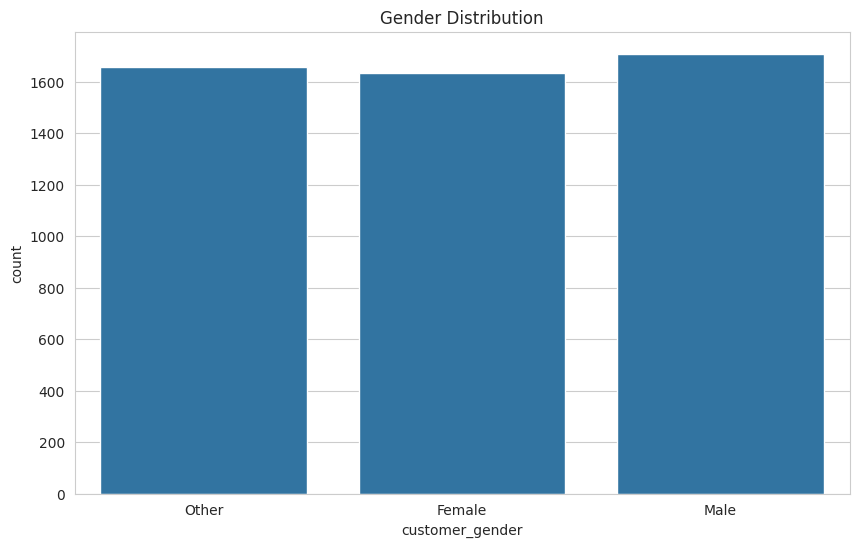

In [38]:
sns.countplot(data=df,
              x='customer_gender')

plt.title("Gender Distribution")
plt.show()

Rating Distribution


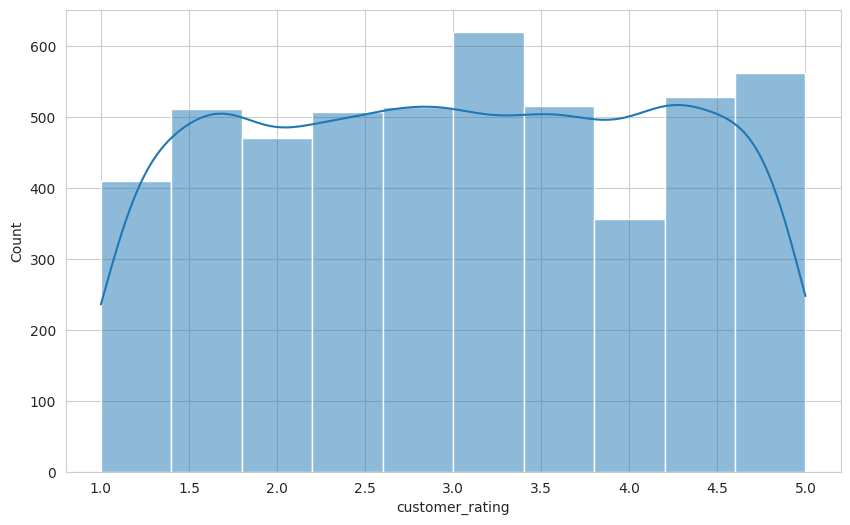

In [39]:
sns.histplot(df['customer_rating'],
             bins=10,
             kde=True)

plt.show()

Payment Method Usage


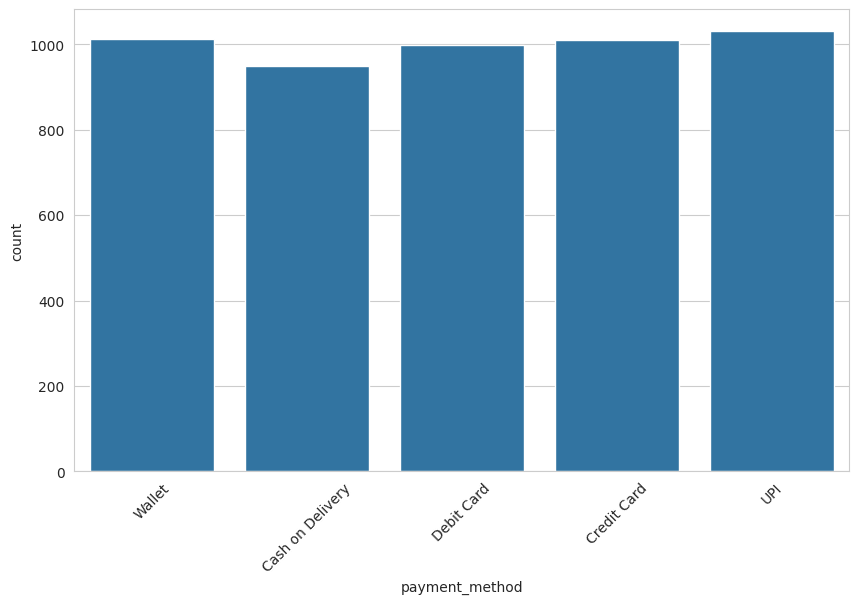

In [40]:
sns.countplot(data=df,
              x='payment_method')

plt.xticks(rotation=45)
plt.show()

Return Distribution


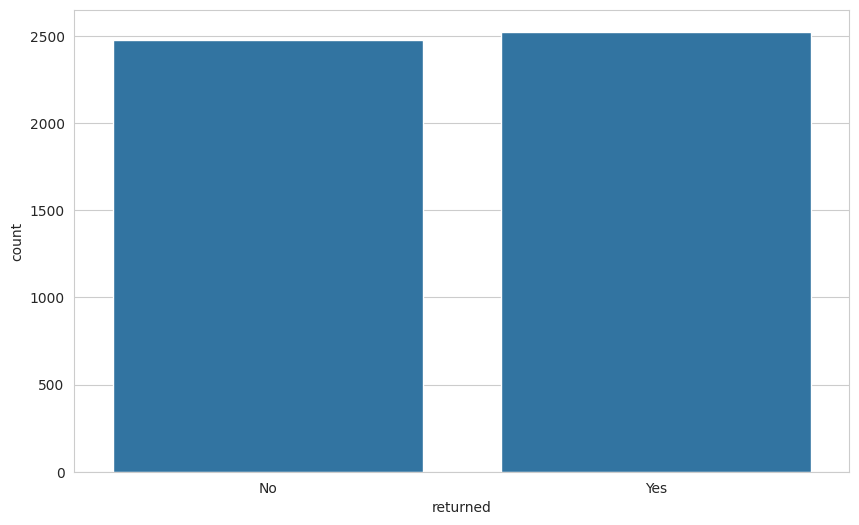

In [41]:
sns.countplot(data=df,
              x='returned')

plt.show()

Delivery Time Distribution

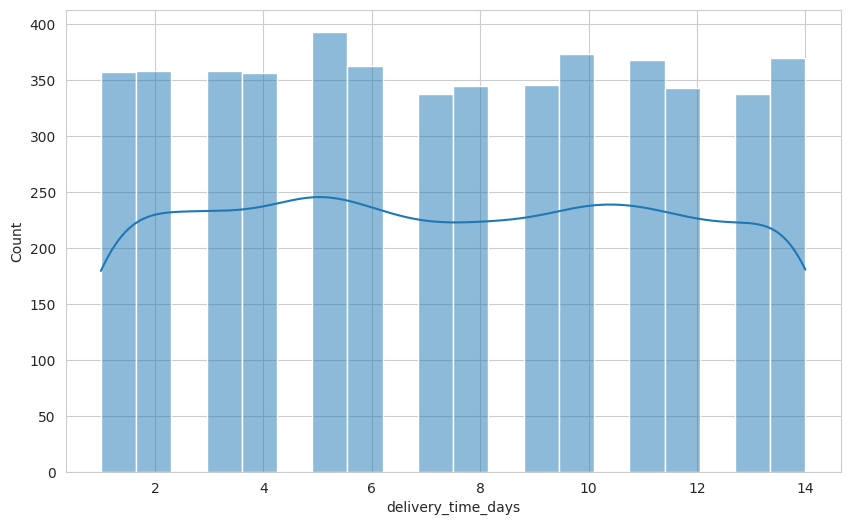

In [42]:
sns.histplot(df['delivery_time_days'],
             bins=20,
             kde=True)

plt.show()

# **Customer Retention Analysis**

Return Rate

In [43]:
return_rate=df['returned'].value_counts(normalize=True)*100

return_rate

,proportion
returned,
Yes,50.5
No,49.5


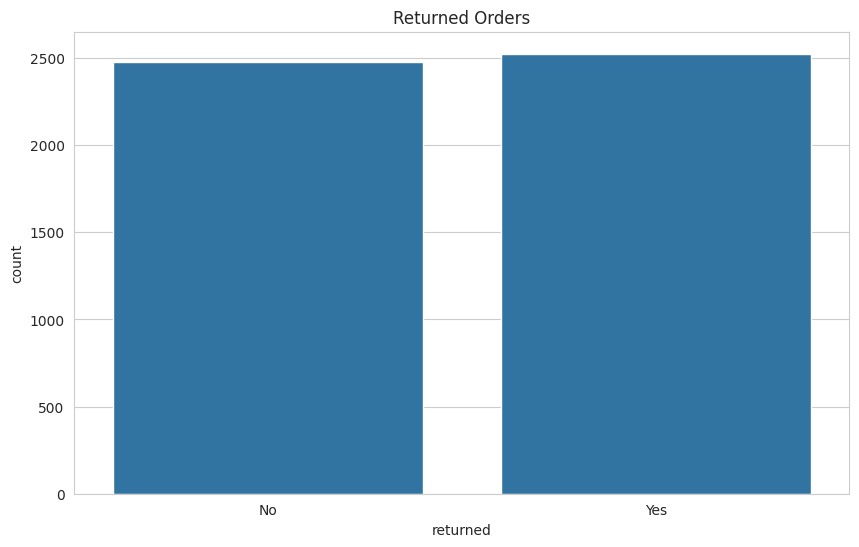

In [44]:
sns.countplot(data=df,
              x='returned')

plt.title("Returned Orders")
plt.show()

Ratings vs Returns

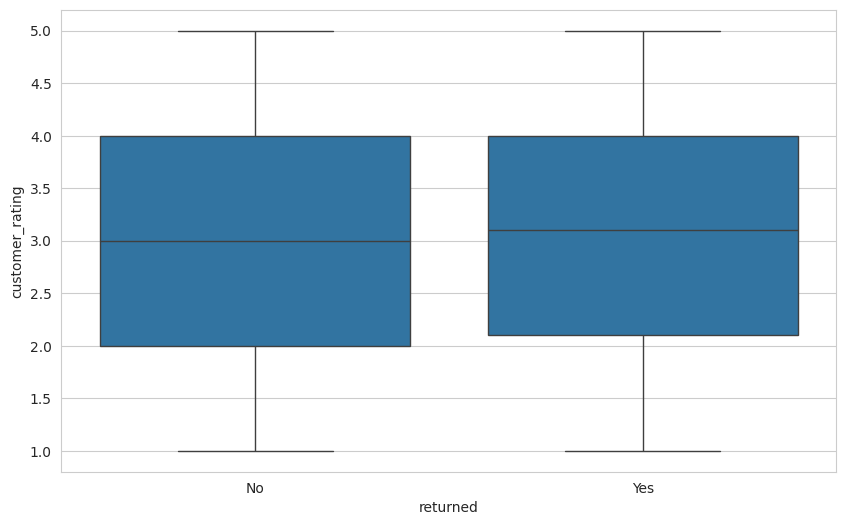

In [45]:
sns.boxplot(data=df,
            x='returned',
            y='customer_rating')

plt.show()

Delivery Time vs Returns


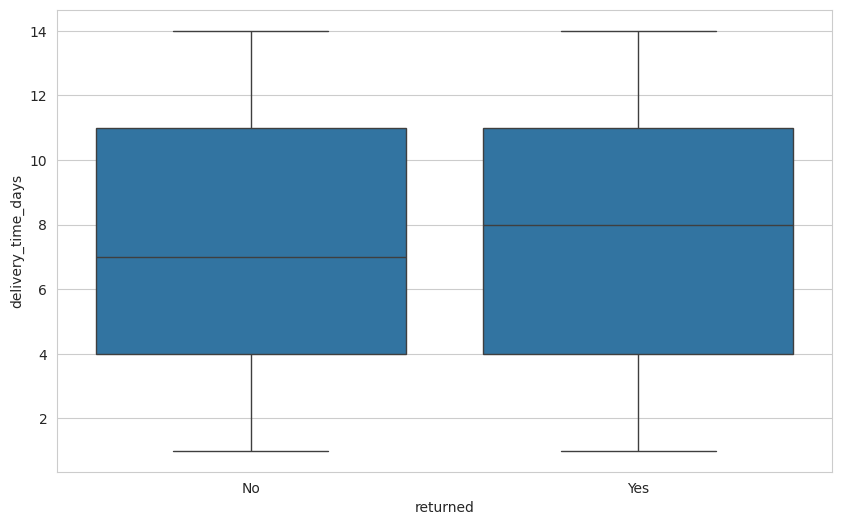

In [46]:
sns.boxplot(data=df,
            x='returned',
            y='delivery_time_days')

plt.show()

Product Category vs Returns

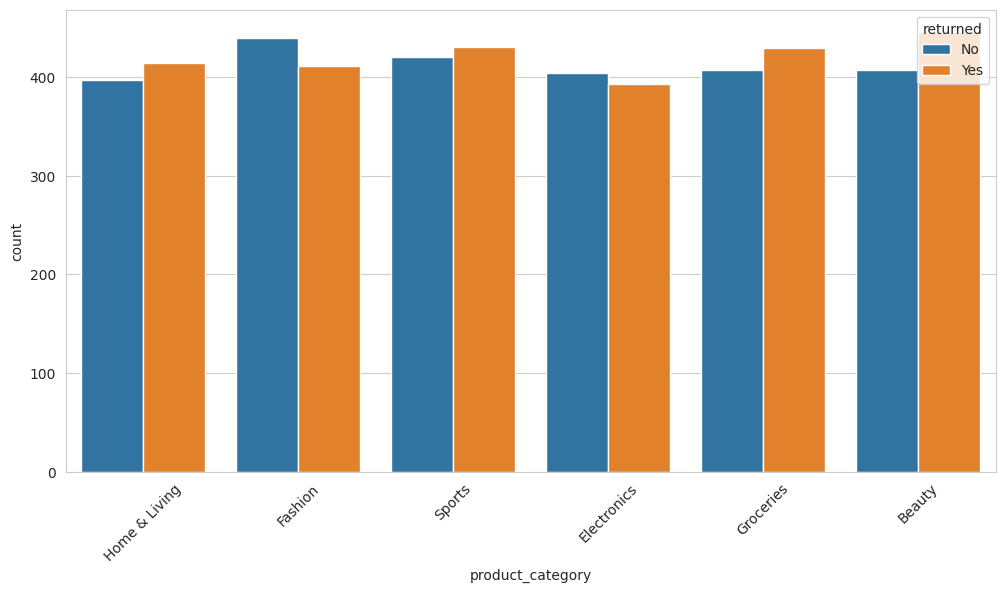

In [47]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x='product_category',
              hue='returned')

plt.xticks(rotation=45)

plt.show()

Payment Method vs Returns

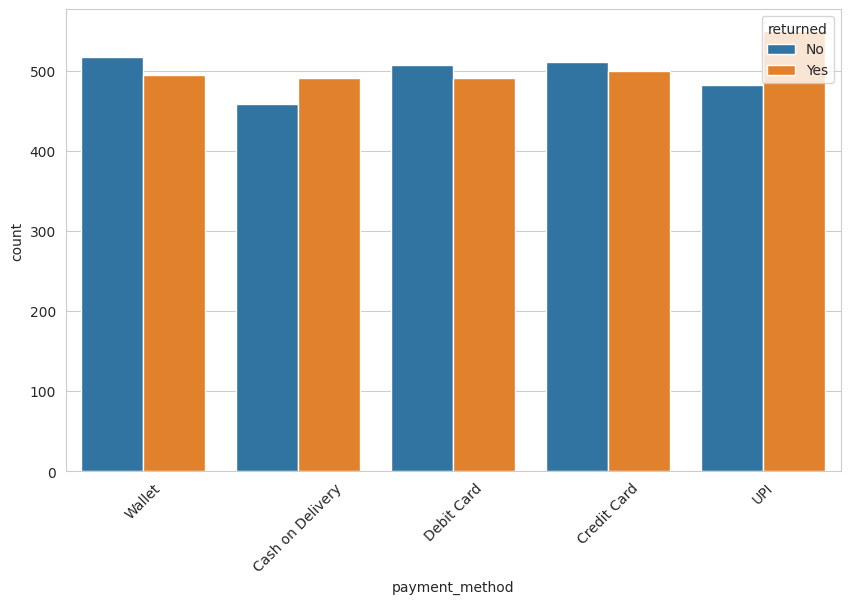

In [48]:
sns.countplot(data=df,
              x='payment_method',
              hue='returned')

plt.xticks(rotation=45)
plt.show()

# **Revenue Analytics**

Total Revenue


In [49]:
df['order_value_usd'].sum()

np.float64(3748361.1900000004)

Average Order Value


In [50]:
df['order_value_usd'].mean()

np.float64(749.6722380000001)

Highest Revenue Category

In [51]:
df.groupby('product_category')['order_value_usd'].sum().sort_values(ascending=False)

,order_value_usd
product_category,
Fashion,654778.14
Sports,640533.99
Groceries,635363.19
Beauty,628714.45
Home & Living,601595.14
Electronics,587376.28


Revenue by Payment Method_
Revenue by Age Group_
Revenue Category Count

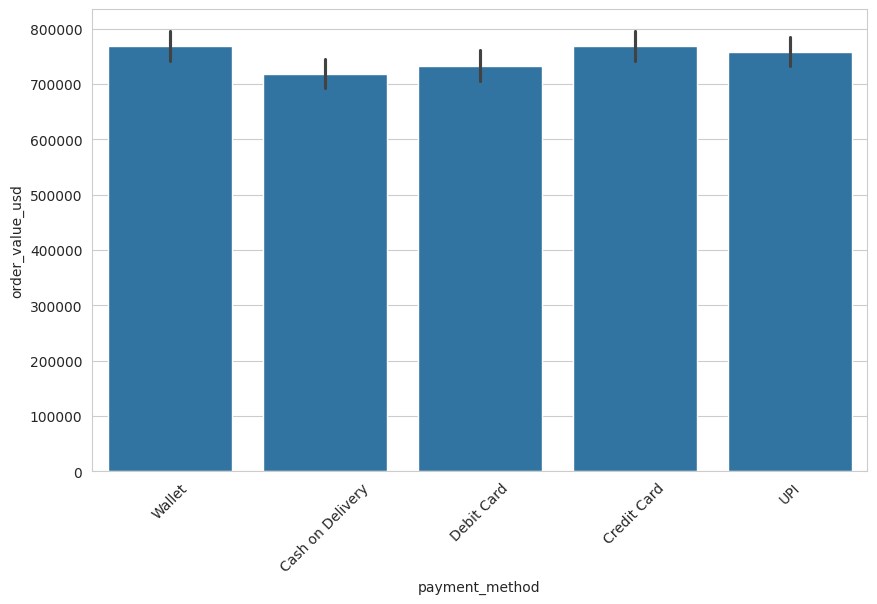

In [52]:
sns.barplot(data=df,
            x='payment_method',
            y='order_value_usd',
            estimator=np.sum)

plt.xticks(rotation=45)
plt.show()


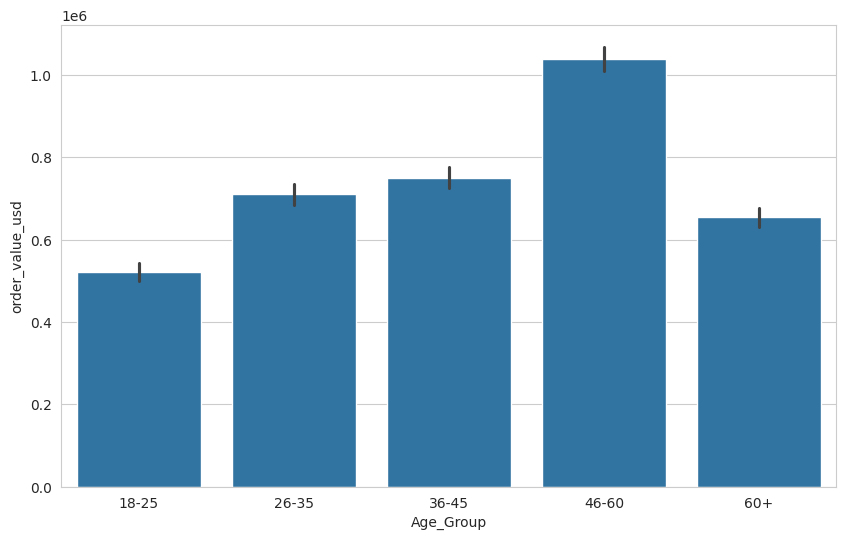

In [53]:
sns.barplot(data=df,
            x='Age_Group',
            y='order_value_usd',
            estimator=np.sum)

plt.show()

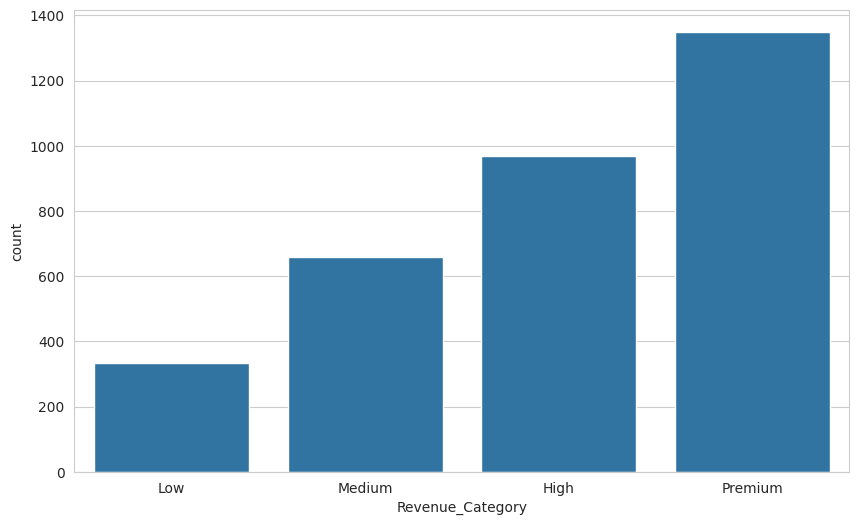

In [54]:
sns.countplot(data=df,
              x='Revenue_Category')

plt.show()

Advanced Visualizations

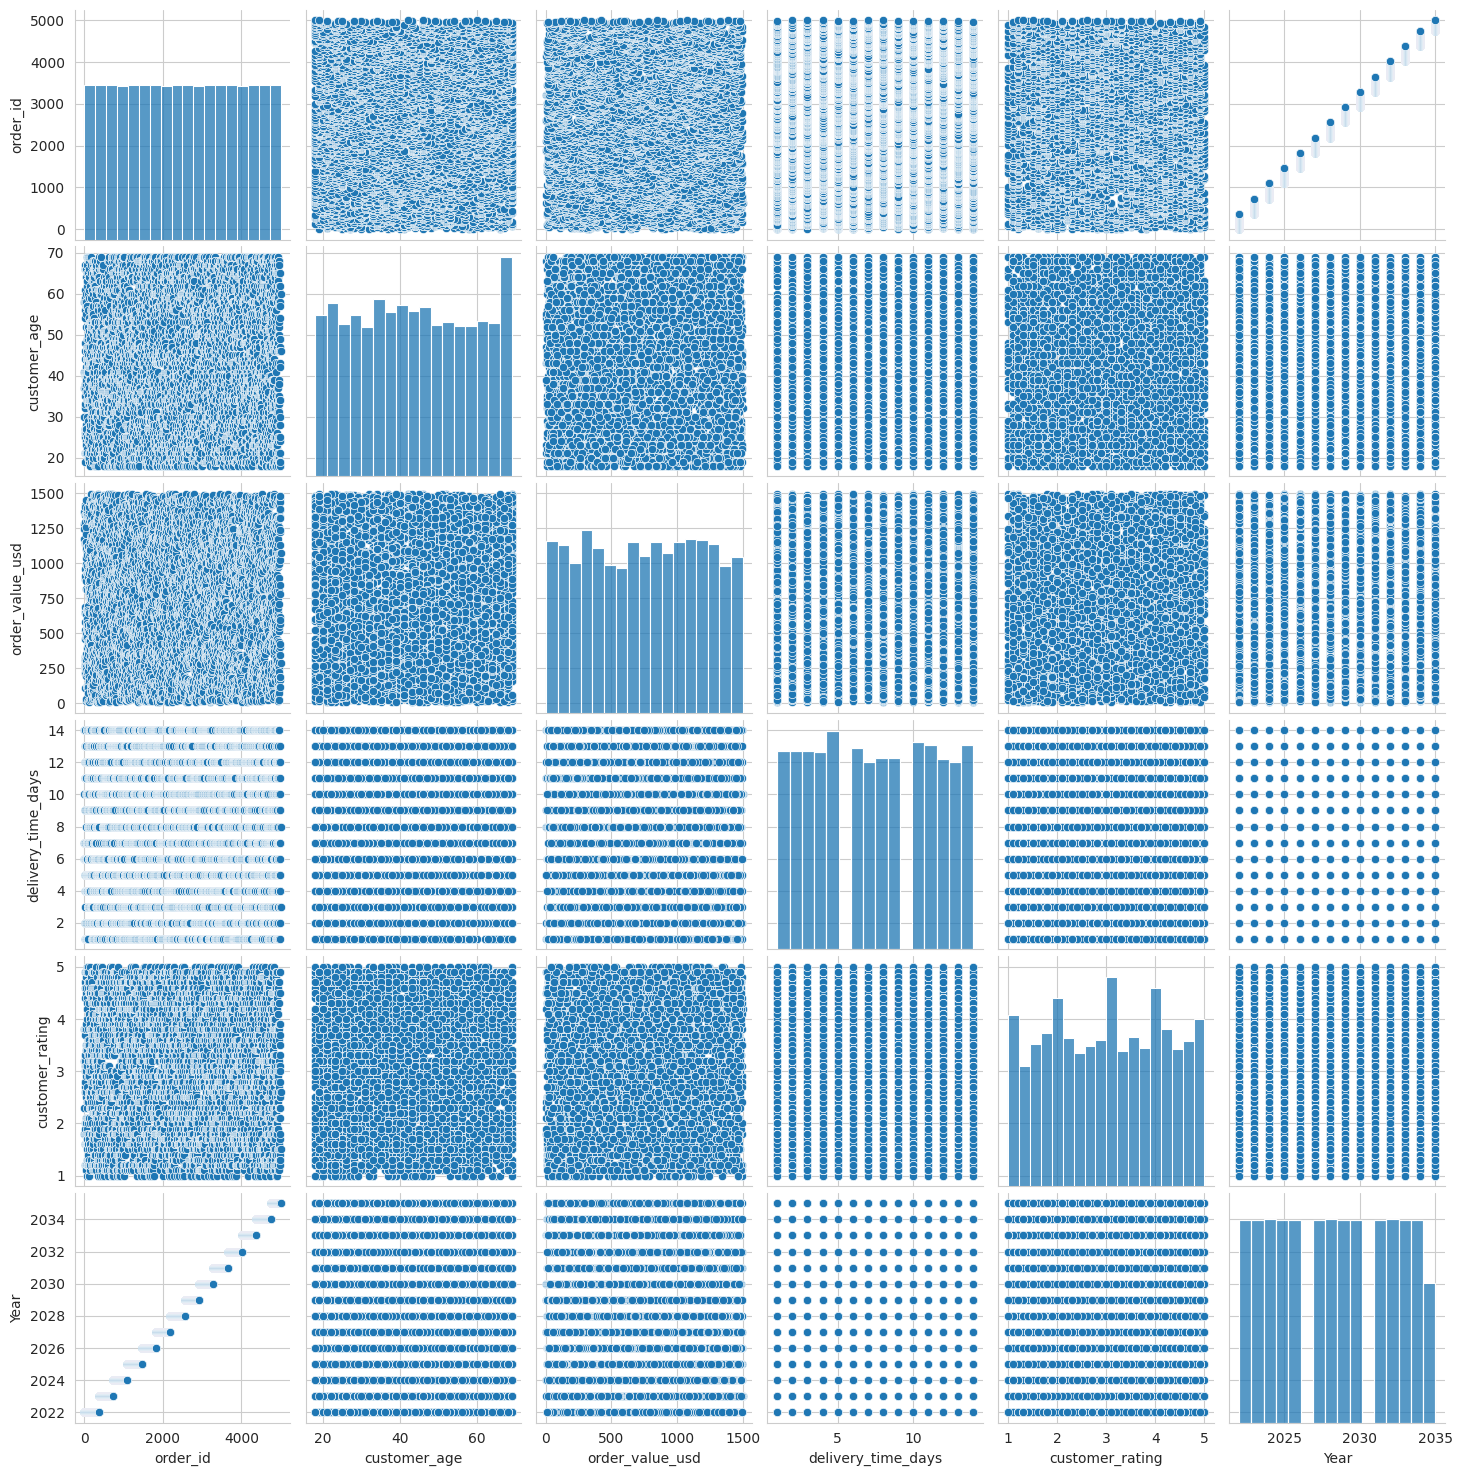

In [55]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

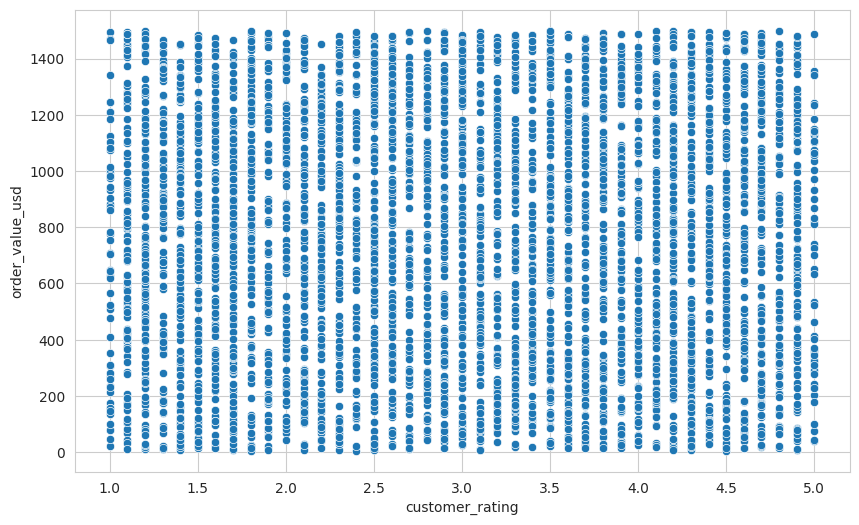

In [56]:
sns.scatterplot(data=df,
                x='customer_rating',
                y='order_value_usd')

plt.show()

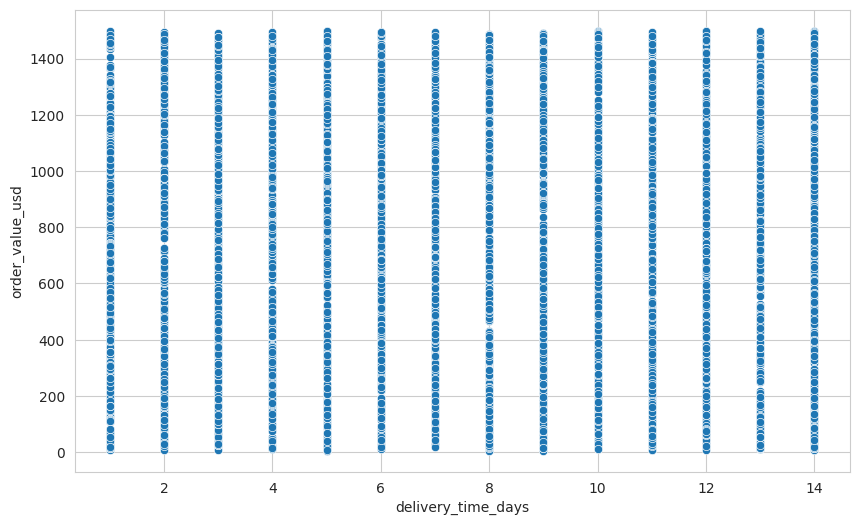

In [57]:
sns.scatterplot(data=df,
                x='delivery_time_days',
                y='order_value_usd')

plt.show()

Boxplot by Product Category

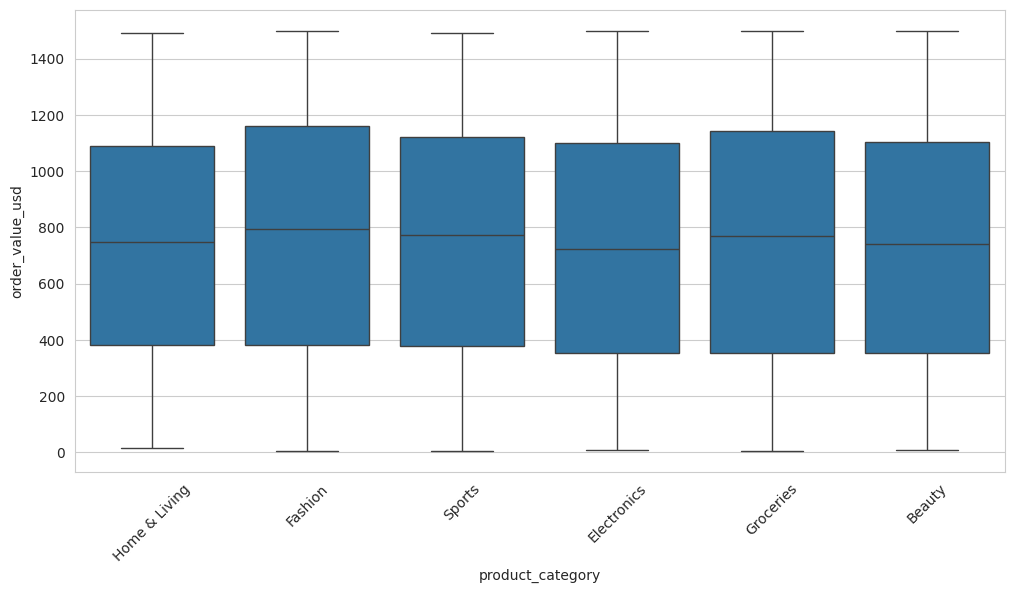

In [58]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x='product_category',
            y='order_value_usd')

plt.xticks(rotation=45)

plt.show()

Heatmap of Product Category vs Payment Method

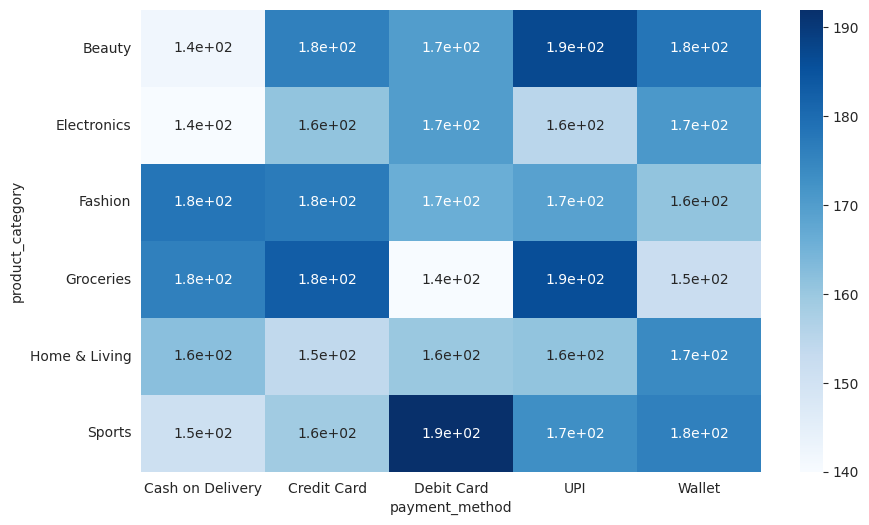

In [59]:
pivot=pd.crosstab(df['product_category'],
                  df['payment_method'])

sns.heatmap(pivot,
            annot=True,
            cmap='Blues')

plt.show()

Statistical Analysis

In [60]:
df.skew(numeric_only=True)

,0
order_id,0.000000
customer_age,0.035637
order_value_usd,-0.018021
delivery_time_days,0.015761
customer_rating,-0.014179
Year,0.011202


In [61]:
z=np.abs(stats.zscore(df.select_dtypes(include=np.number)))

np.where(z>3)

(array([], dtype=int64), array([], dtype=int64))

In [62]:
df.kurt(numeric_only=True)

,0
order_id,-1.200000
customer_age,-1.180878
order_value_usd,-1.206866
delivery_time_days,-1.213697
customer_rating,-1.190199
Year,-1.198226
